In [2]:
import numpy as np
import pandas as pd
import os
import re
import json

import matplotlib.pyplot as plt

In [3]:
def load_data(data_root_dir):
    total_data = []
    
    for dirname in os.listdir(data_root_dir):
        if dirname.endswith('.npy') or dirname.endswith('.json'):
            continue
        if dirname == 'img':
            continue
        # extract parameters from the directory name
        match = re.match(r'w_in_amp_(\d+)p(\d+)_gbar_(\d+)p(\d+)', dirname)
        w_in_amp = eval(f"{match.group(1)}.{match.group(2)}")
        gbar = eval(f"{match.group(3)}.{match.group(4)}")
        print(f"Processing: {dirname} with w_in_amp={w_in_amp}, gbar={gbar}")
        # load the data
        data = {}
        data['w_in_amp'] = w_in_amp
        data['gbar'] = gbar
        data['dirname'] = dirname
        data['output_train'] = np.load(os.path.join(data_root_dir, dirname, 'output_data_train.npy'))
        data['output_test'] = np.load(os.path.join(data_root_dir, dirname, 'output_data_test.npy'))
        total_data.append(data)
    return total_data

In [4]:
import json


data_root_dir = os.path.join(os.getcwd(), 'bfm_output', 'lorenz_current_test')
seed = 1
np.random.seed(seed)

params_json = json.load(open(os.path.join(data_root_dir, 'reservoir_params.json'), 'r'))

for key, value in params_json.items():
    print(f"{key}: {value}")

model_cls: {'__type__': 'class', 'module': 'rctorch.models.morris_lecar', 'name': 'MorrisLecarCurrent'}
n_input: 3
n_output: 3
Ne: 4000
Ni: 1000
dt: 0.1
BIAS: {'__type__': 'numpy.ndarray', 'dtype': 'float64', 'shape': [5000, 1], 'data': [[65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [65.0], [6

/home/ali/Code/research/ml_force_research/hpc/bfm_output/lorenz_current_test


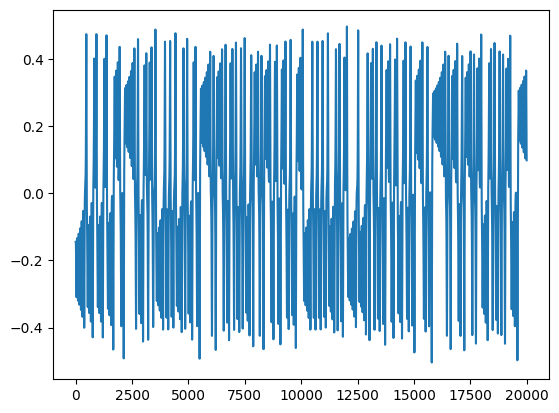

In [5]:
# data_root_dir = os.path.join(os.getcwd(), 'hulk_run', 'lorenz_current_grand')
print(data_root_dir)

sup = np.load(os.path.join(data_root_dir, 'supervisor.npy'))

dt = 1e-1
nt = sup.shape[0]
t_vec = np.arange(nt) * dt


plt.plot(t_vec, sup[:, 0], label='x')
plt.show()

In [6]:
len(os.listdir(data_root_dir))

49

In [7]:
nt_split = int(nt / 2)
sup_test = sup[nt_split:]
sup_train = sup[:nt_split]

In [8]:
from scipy.signal import find_peaks

def get_return_map(data):
    peaks = data[find_peaks(data, distance=400)[0]]
    # peaks = peaks[peaks > 0]
    return_map = np.vstack([peaks[:-1], peaks[1:]])
    return return_map

In [9]:
def get_histogram(output_data, sup_test, n_bins=100):
    """
    Get histogram of data.
    """
    hists = []
    for axis in range(sup.shape[1]):
        sup_hist, bins = np.histogram(sup_test[:, axis], bins=n_bins, density=True)
        output_hist, bins = np.histogram(output_data[:, axis], bins=bins, density=True)
        hists.append((sup_hist, output_hist, bins))
    return hists

In [10]:
def kl_div(hists: list[tuple]):
    """
    Calculate the KL divergence between two multi-dimensional histograms.
    """
    kl_div_values = []
    for i in range(len(hists)):
        sup_hist, output_hist, bins = hists[i]
        bin_size = bins[1] - bins[0]
        # Ensure both histograms are normalized
        sup_hist = sup_hist / np.sum(sup_hist) * bin_size
        output_hist = output_hist / np.sum(output_hist) * bin_size
        # Avoid division by zero and log of zero
        sup_hist = np.where(sup_hist == 0, 1e-10, sup_hist)
        output_hist = np.where(output_hist == 0, 1e-10, output_hist)
        # Calculate KL divergence
        kl_div_value = np.sum(sup_hist * np.log(sup_hist / output_hist))
        kl_div_values.append(kl_div_value)
        
    return kl_div_values

In [12]:
metrics = []

for dirname in os.listdir(data_root_dir):
    if dirname.endswith('.npy') or dirname.endswith('.json'):
        continue
    if dirname == 'img':
        continue
    # extract parameters from the directory name
    match = re.match(r'w_in_amp_(\d+)p(\d+)_gbar_(\d+)p(\d+)', dirname)
    if not match:
        continue
    w_in_amp = eval(f"{match.group(1)}.{match.group(2)}")
    gbar = eval(f"{match.group(3)}.{match.group(4)}")
    print(f"Processing: {dirname} with w_in_amp={w_in_amp}, gbar={gbar}")
    # load the data
    data = {}
    data['Q'] = w_in_amp
    data['gbar'] = gbar
    data['dirname'] = dirname
    
    output_test = np.load(os.path.join(data_root_dir, dirname, 'output_data_test.npy'))
    data['output_test'] = output_test
    data['kl_div'] = kl_div(get_histogram(output_test, sup_test))
    data['return_map'] = get_return_map(output_test[:, -1])
    metrics.append(data)

Processing: w_in_amp_20p0000_gbar_5p0000 with w_in_amp=20.0, gbar=5.0
Processing: w_in_amp_20p0000_gbar_10p8333 with w_in_amp=20.0, gbar=10.8333
Processing: w_in_amp_20p0000_gbar_16p6667 with w_in_amp=20.0, gbar=16.6667
Processing: w_in_amp_20p0000_gbar_22p5000 with w_in_amp=20.0, gbar=22.5
Processing: w_in_amp_20p0000_gbar_28p3333 with w_in_amp=20.0, gbar=28.3333
Processing: w_in_amp_20p0000_gbar_34p1667 with w_in_amp=20.0, gbar=34.1667
Processing: w_in_amp_20p0000_gbar_40p0000 with w_in_amp=20.0, gbar=40.0
Processing: w_in_amp_83p3333_gbar_5p0000 with w_in_amp=83.3333, gbar=5.0
Processing: w_in_amp_83p3333_gbar_10p8333 with w_in_amp=83.3333, gbar=10.8333
Processing: w_in_amp_83p3333_gbar_16p6667 with w_in_amp=83.3333, gbar=16.6667
Processing: w_in_amp_83p3333_gbar_22p5000 with w_in_amp=83.3333, gbar=22.5
Processing: w_in_amp_83p3333_gbar_28p3333 with w_in_amp=83.3333, gbar=28.3333
Processing: w_in_amp_83p3333_gbar_34p1667 with w_in_amp=83.3333, gbar=34.1667
Processing: w_in_amp_146p6

In [13]:
len(metrics)

45

In [15]:
from typing import Any, List, Dict, Tuple

def find_param_range(total_stacked: List[List[Dict[str, Any]]]) -> Dict[str, Tuple[float, float]]:
    Q_vals = []
    gbar_vals = []
    for row in total_stacked:
        for d in row:
            if 'Q' in d and d['Q'] is not None:
                Q_vals.append(float(d['Q']))
            if 'gbar' in d and d['gbar'] is not None:
                gbar_vals.append(float(d['gbar']))
    if not Q_vals or not gbar_vals:
        raise ValueError("No 'Q' or 'gbar' values found in total_stacked")
    return {'Q': (min(Q_vals), max(Q_vals)), 'gbar': (min(gbar_vals), max(gbar_vals))}

In [16]:
total_sorted = sorted(metrics, key=lambda x: x['Q'])

def sort_stacked(total_sorted):
    total_stacked = []
    Qs = [data['Q'] for data in total_sorted]
    for value in np.unique(Qs):
        dummy = list()
        for data in total_sorted:
            if data['Q'] == value:
                dummy.append(data)
        total_stacked.append(sorted(dummy, key=lambda x: x['gbar']))

    for lst in total_stacked:
        for data in lst:
            print(f"{data['Q']}, {data['gbar']}")
    return total_stacked

total_stacked = sort_stacked(total_sorted)

20.0, 5.0
20.0, 10.8333
20.0, 16.6667
20.0, 22.5
20.0, 28.3333
20.0, 34.1667
20.0, 40.0
83.3333, 5.0
83.3333, 10.8333
83.3333, 16.6667
83.3333, 22.5
83.3333, 28.3333
83.3333, 34.1667
146.6667, 5.0
146.6667, 10.8333
146.6667, 16.6667
146.6667, 22.5
146.6667, 28.3333
146.6667, 34.1667
146.6667, 40.0
210.0, 5.0
210.0, 10.8333
210.0, 16.6667
210.0, 22.5
210.0, 28.3333
210.0, 34.1667
273.3333, 5.0
273.3333, 10.8333
273.3333, 16.6667
273.3333, 22.5
273.3333, 28.3333
273.3333, 34.1667
336.6667, 5.0
336.6667, 10.8333
336.6667, 16.6667
336.6667, 22.5
336.6667, 28.3333
336.6667, 34.1667
336.6667, 40.0
400.0, 5.0
400.0, 10.8333
400.0, 16.6667
400.0, 22.5
400.0, 28.3333
400.0, 34.1667


In [17]:
save_dir = os.path.join(data_root_dir, 'img')

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [18]:
original_return_map = get_return_map(sup_test[:, -1])

In [22]:
import os, sys

sys.path.append(os.path.join(os.getcwd(), '..'))

from morris_lecar.plot_styles import set_thesis_style

set_thesis_style()

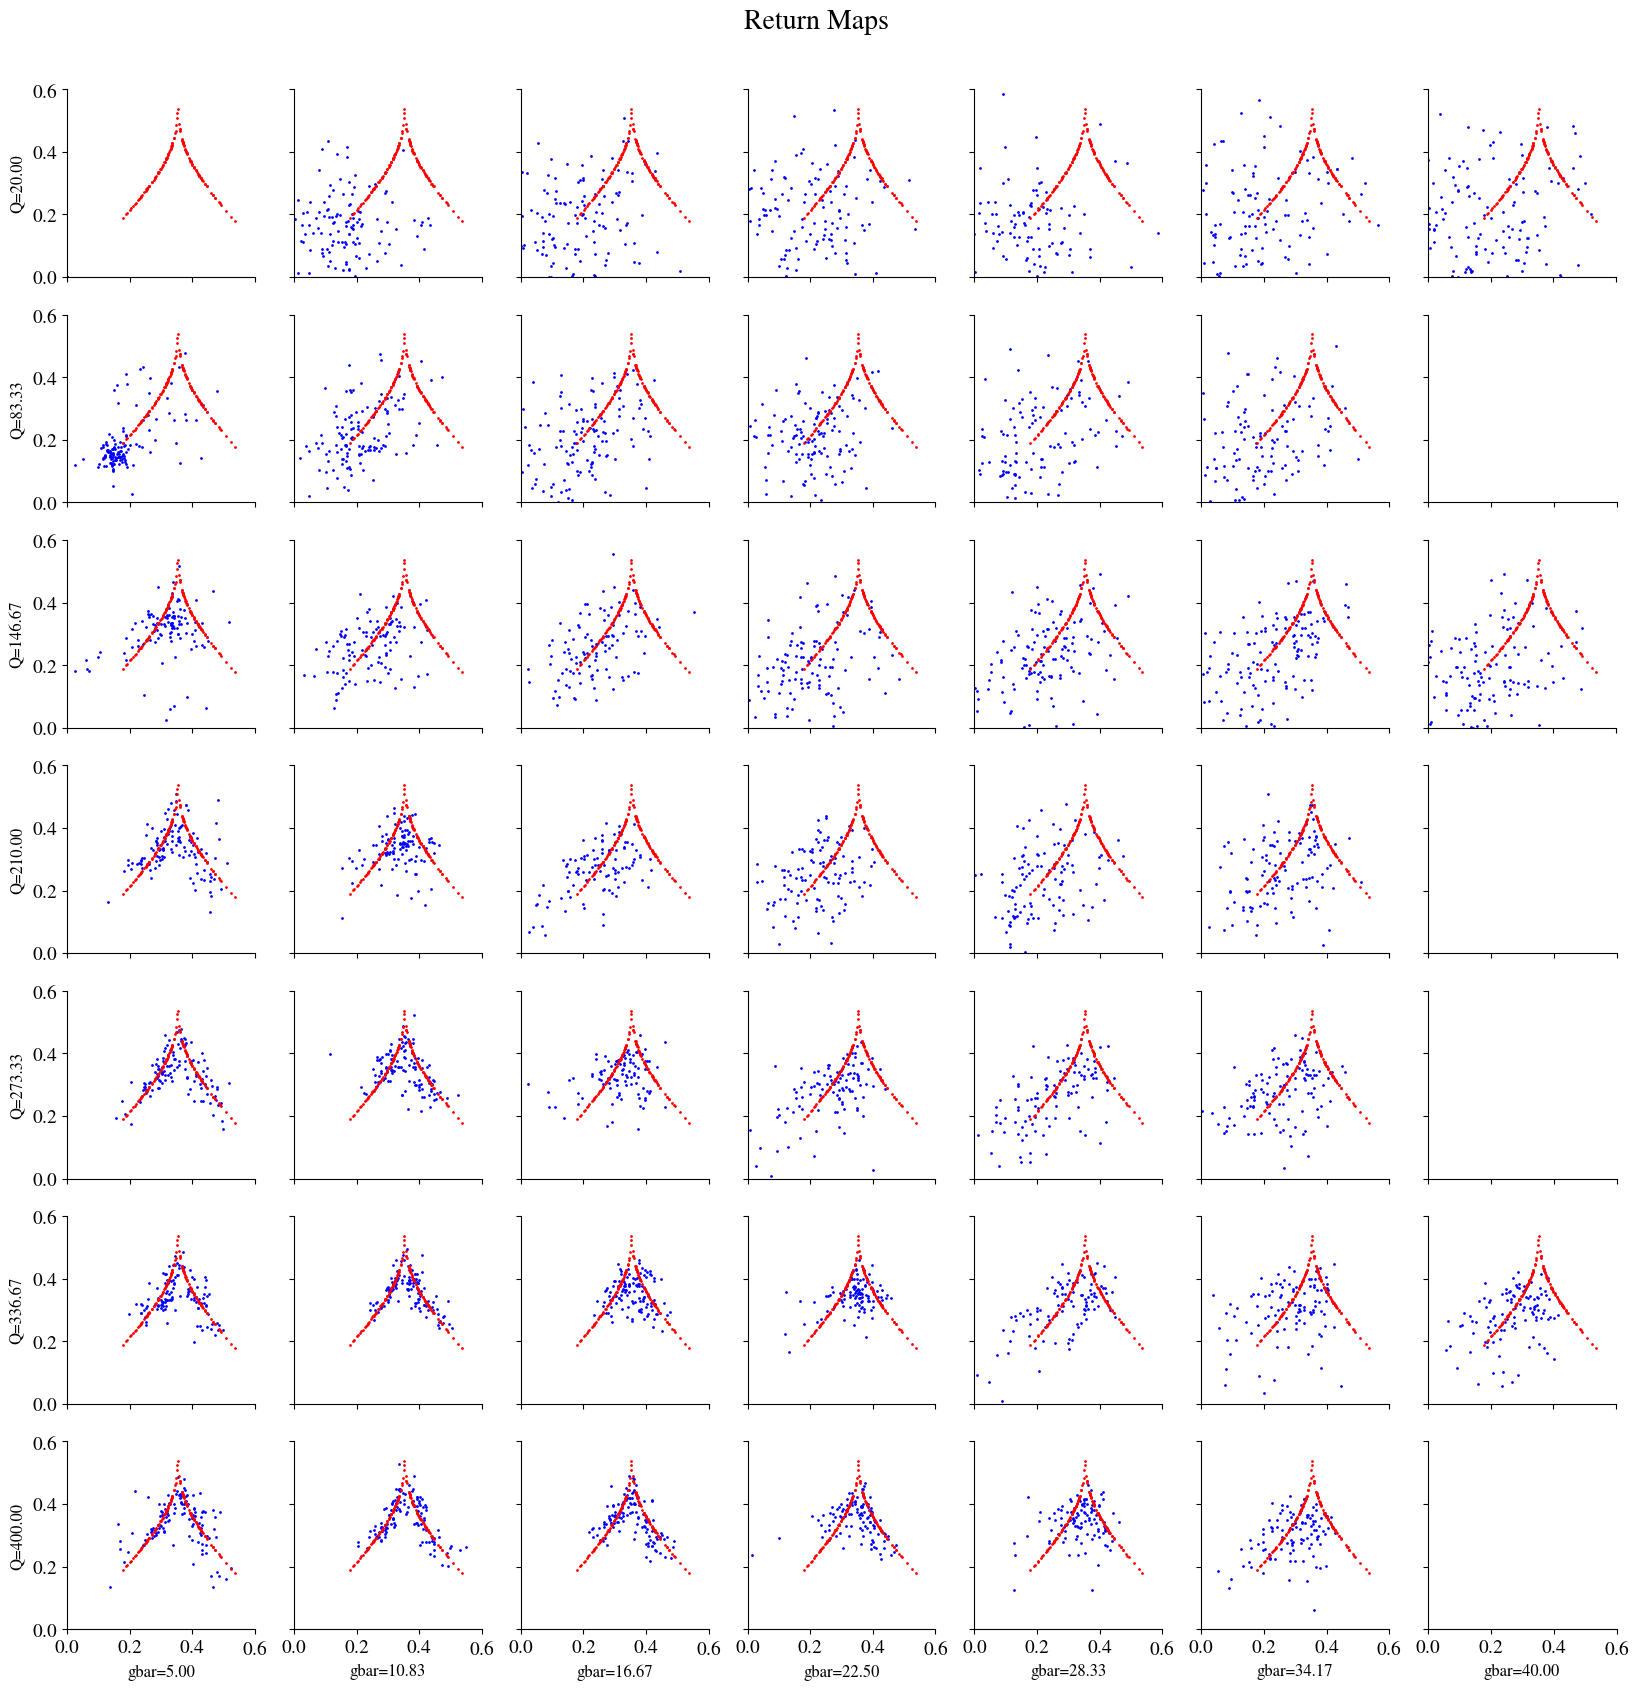

In [26]:
fig, ax = plt.subplots(len(total_stacked), len(total_stacked[0]), figsize=(20, 20), sharex=True, sharey=True)

for i in range(len(total_stacked)):
    ax[i, 0].set_ylabel(f"Q={total_stacked[i][0]['Q']:.2f}", fontsize=12)
    for j in range(len(total_stacked[i])):
        data = total_stacked[i][j]
        ax[i, j].scatter(data['return_map'][0], data['return_map'][1], c='b', s=1)
        ax[i, j].scatter(original_return_map[0], original_return_map[1], c='r', s=1)
        ax[i, j].set_xlim(0, 0.6)
        ax[i, j].set_ylim(0, 0.6)
        ax[i, j].set_aspect('equal', adjustable='box')

for i in range(len(total_stacked[0])):
    ax[-1, i].set_xlabel(f"gbar={total_stacked[0][i]['gbar']:.2f}", fontsize=12)
plt.suptitle("Return Maps", fontsize=20, y=0.92)
plt.savefig(os.path.join(save_dir, 'return_maps.pdf'), bbox_inches='tight')
plt.show(fig)

In [27]:
kl_div_values = [[total_stacked[i][j]['kl_div'] for j in range(len(total_stacked[i]))] for i in range(len(total_stacked))]
missing_rows: list[int] = [1, 3, 4, 6]
for row_id in missing_rows:
    kl_div_values[row_id].append([np.nan] * 3)
    
for row in kl_div_values:
    print(len(row))

losses = np.array(kl_div_values).sum(axis=2)
losses[0, 0] = np.nan

7
7
7
7
7
7
7


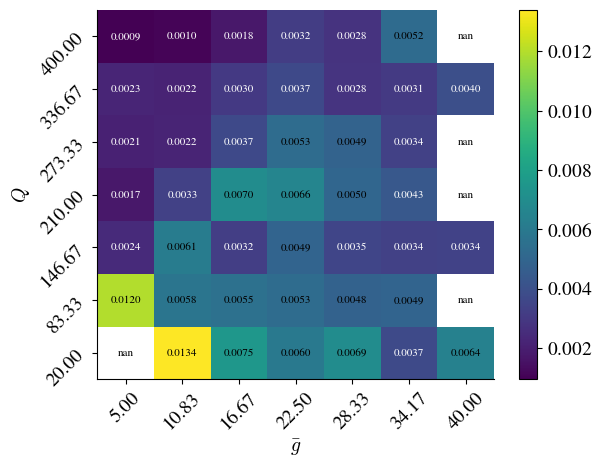

In [31]:
cl = plt.pcolormesh(losses, cmap="viridis")
mean_val = np.nanmean(losses)
for i in range(losses.shape[0]):
    for j in range(losses.shape[1]):
        val = losses[i, j]
        txt = "nan" if np.isnan(val) else f"{val:.4f}"
        color = "white" if (not np.isnan(val) and val < mean_val) else "black"
        plt.text(j + 0.5, i + 0.5, txt, ha="center", va="center", color=color, fontsize=8)
plt.xticks(
    ticks=np.arange(0.5, 7.0, 1.0),
    labels=[f"{total_stacked[0][i]['gbar']:.2f}" for i in range(len(total_stacked[0]))],
    rotation=45,
)
plt.yticks(
    ticks=np.arange(0.5, 7.0, 1.0),
    labels=[f"{total_stacked[i][0]['Q']:.2f}" for i in range(len(total_stacked))],
    rotation=45,
)
plt.xlabel(r"$\bar{g}$")
plt.ylabel(r"$Q$")
plt.colorbar(cl)
plt.show()

In [40]:
p_sparsity = 0.01
N = 5_000
w_mock = np.random.normal(0, 1/np.sqrt(N*p_sparsity), size=(N, N))

np.abs(w_mock).mean(), np.abs(w_mock).min(), np.abs(w_mock).max()

(np.float64(0.11284675418901667),
 np.float64(4.32642108801611e-09),
 np.float64(0.8118282703097023))

In [41]:
np.where(losses == np.nanmin(losses))

(array([6]), array([0]))

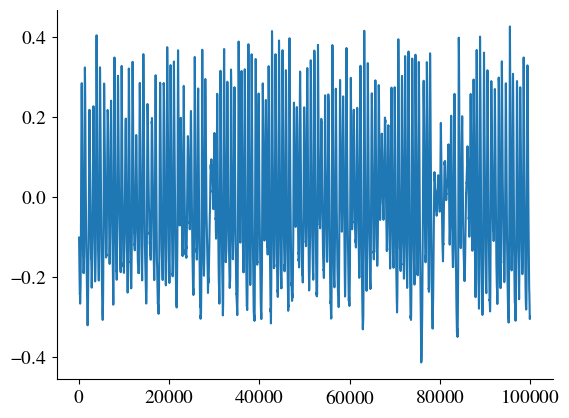

In [42]:
plt.plot(data['output_test'][:, -1])
plt.show()

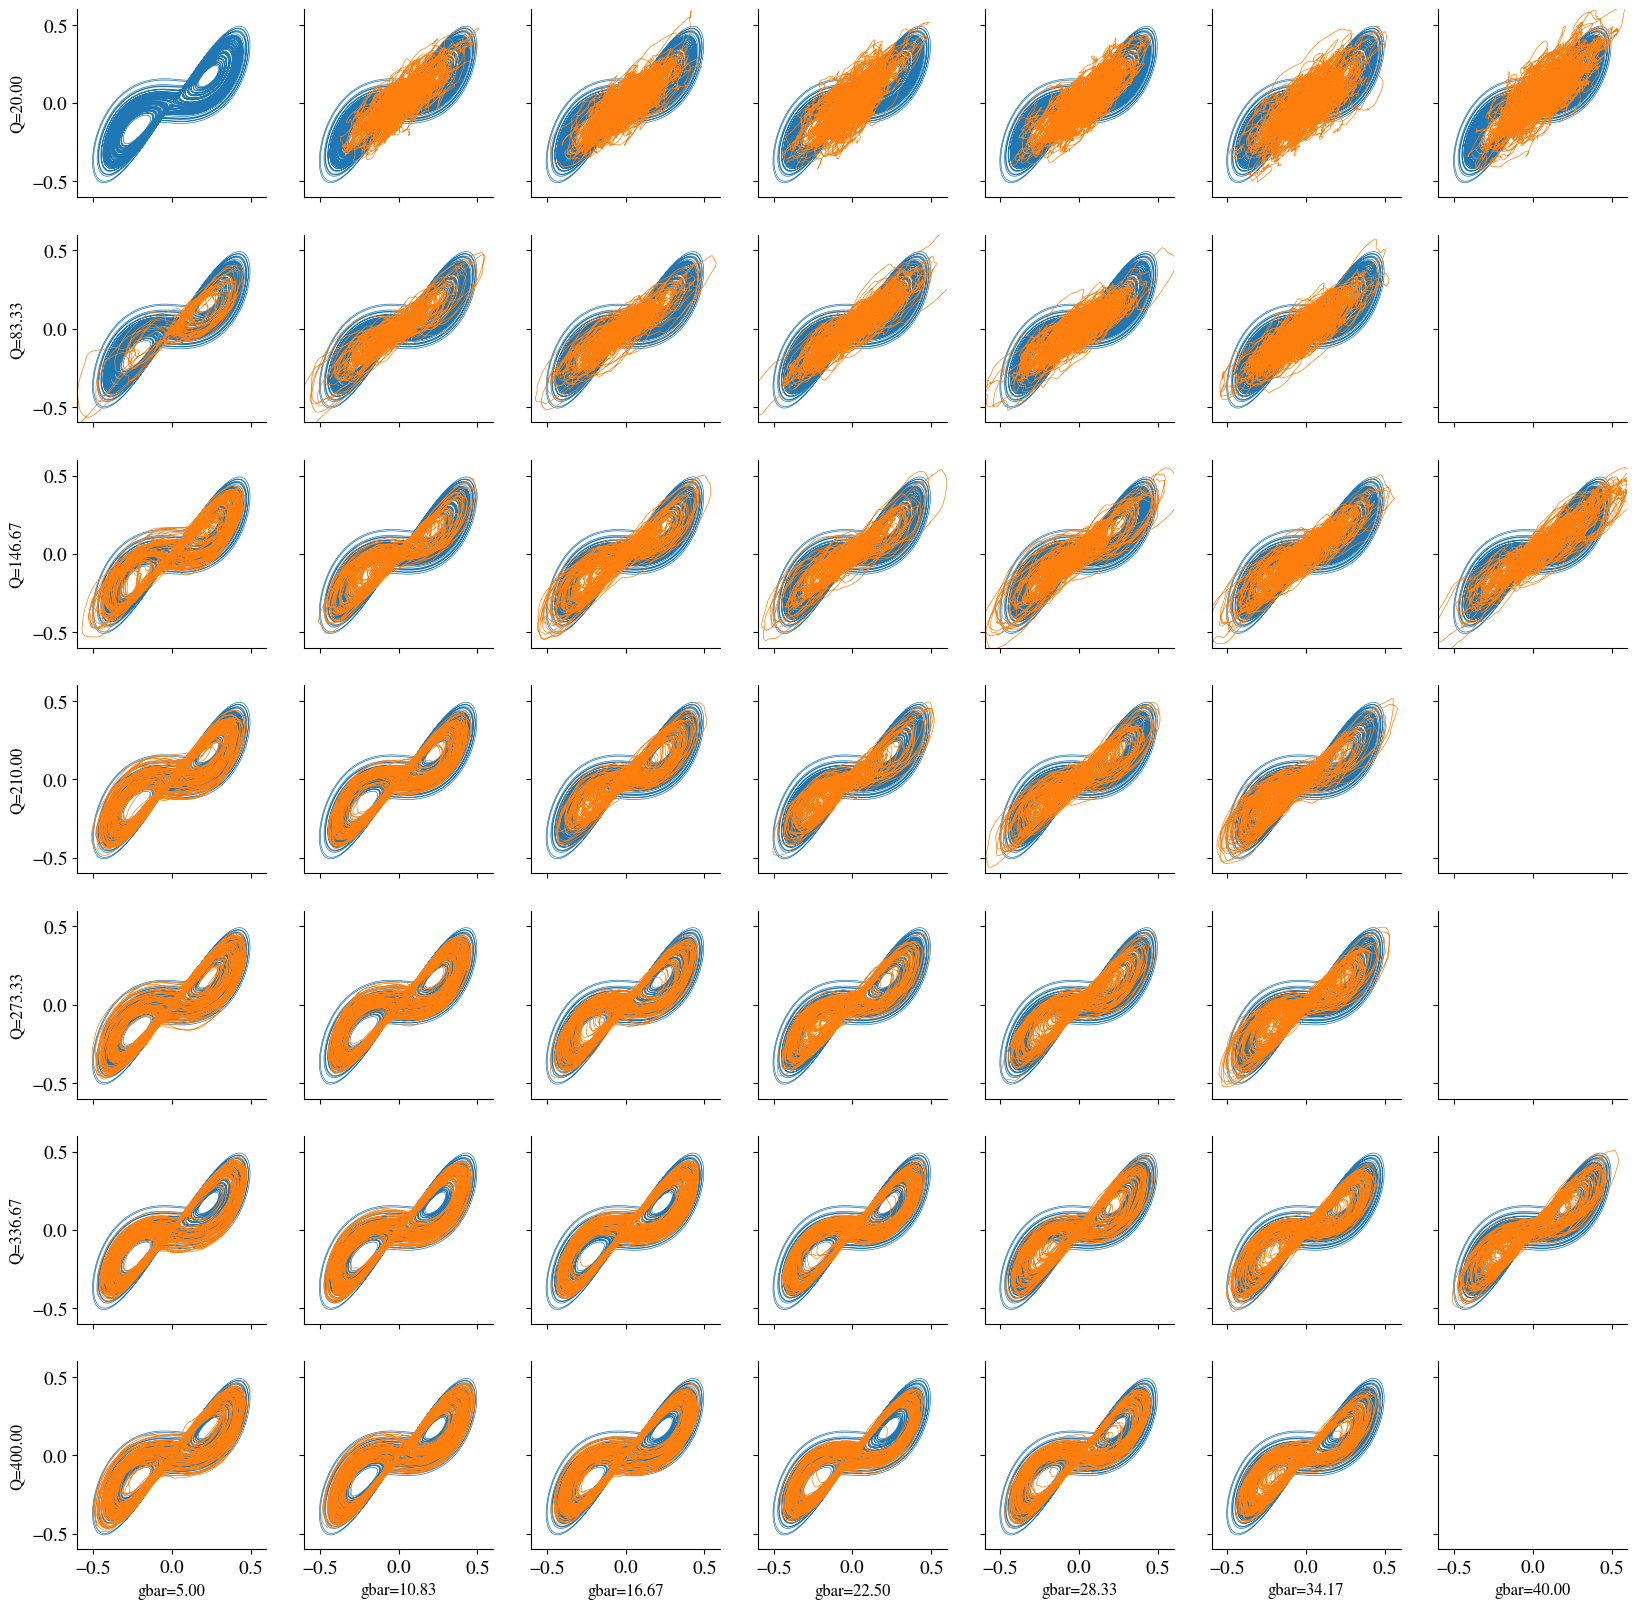

In [48]:
fig, ax = plt.subplots(len(total_stacked), len(total_stacked[0]), figsize=(20, 20), sharex=True, sharey=True)

for i in range(len(total_stacked)):
    ax[i, 0].set_ylabel(f"Q={total_stacked[i][0]['Q']:.2f}", fontsize=12)
    for j in range(len(total_stacked[i])):
        data = total_stacked[i][j]
        ax[i, j].plot(sup[nt_split:, 0], sup[nt_split:, 1], lw=.5)
        ax[i, j].plot(data['output_test'][:, 0], data['output_test'][:, 1], lw=.5)
        # ax[i, j].set_title(f"Q={data['Q']:.1f}, gbar={data['gbar']:.1f}")

for i in range(len(total_stacked[0])):
    ax[-1, i].set_xlabel(f"gbar={total_stacked[0][i]['gbar']:.2f}", fontsize=12)

plt.xlim(-.6, .6)
plt.ylim(-.6, .6)
# plt.savefig(os.path.join(save_dir, 'x_y_phase_space.png'), dpi=300, bbox_inches='tight')
plt.show()